<a href="https://colab.research.google.com/github/mabitha-7/mlops_training/blob/main/TASK_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT THE REQUIRED LIBRARIES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

READING THE DATASET AND PRINT THE HEAD OF THE DATASET

In [ ]:
df = pd.read_csv("/content/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


SELECT THE X AND Y FOR THIS SCENARIO

In [ ]:
x=df[['Rotational speed [rpm]']]
y=df[['Process temperature [K]']]

CREATE A MODEL FOR THIS SCENARIO

In [ ]:
model=LinearRegression()

TRAIN THE MODEL WHERE WE CREATE IN SELECTING X AND Y

In [ ]:
model.fit(x,y)

LinearRegression()

PREDICT THE MODEL

In [ ]:
predictions=model.predict(x)
predictions

array([[310.0075101 ],
       [309.98469705],
       [309.99905491],
       ...,
       [310.02250609],
       [309.98469705],
       [309.99937398]])

ANALAYSE THE SAHAPE

In [ ]:
df.shape

(10000, 14)

MEAN SQUARE ERROR

In [ ]:
mse=mean_squared_error(y,predictions)
mse

2.2004291212555707

PLOT THE GRAPH

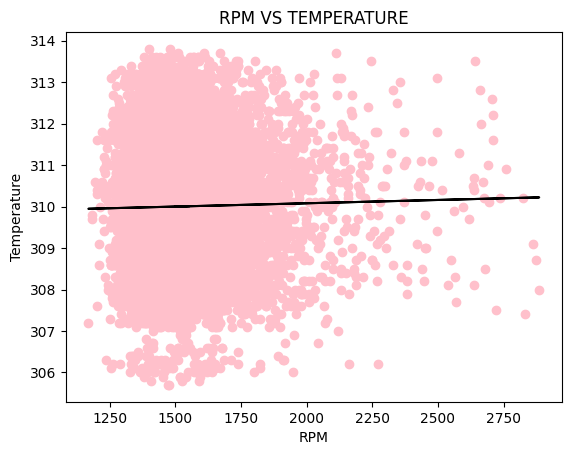

In [ ]:
plt.scatter(df['Rotational speed [rpm]'],y,color='pink')
plt.plot(df['Rotational speed [rpm]'],predictions,color='black')
plt.xlabel("RPM")
plt.ylabel("Temperature")
plt.title("RPM VS TEMPERATURE")
plt.show()

MULTIVARIABLE REGRESSION

In [ ]:
x_multi = df[['Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']]

TAKING THE Y OF MULTI VARIABLE

In [ ]:
y_multi=df[['Process temperature [K]']]

CREATE A MODEL FOR MULTI VARIABLE

In [ ]:
multimodel=LinearRegression()

TRAIN THE MULTI LINEAR MODEL

In [ ]:
multimodel.fit(x_multi,y_multi)

LinearRegression()

PREDICT THE MODEL

In [ ]:
mulpredictions=multimodel.predict(x_multi)
mulpredictions

array([[309.97965461],
       [309.95153965],
       [309.98004593],
       ...,
       [309.99285537],
       [309.96244912],
       [309.97178674]])

CALCULATE MSE

In [ ]:
mulmse=mean_squared_error(y_multi,multi_predictions)
mulmse

2.1999528448038213

SAVING THE MODEL

In [ ]:
import joblib

SAVES IN A PICKLE PACKAGE

In [ ]:
joblib.dump(multi_model,"ai4i2020.pkl")

['ai4i2020.pkl']

LOADING THE SAVED MODEL

In [ ]:
lmodel=joblib.load("/content/ai4i2020.pkl")

PREDICT THE NEW MACHINE READING

In [ ]:
new=lmodel.predict([[1500,40,20]])
new

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[309.96827413]])

ONE HOT ENCODING

In [ ]:
print(df['Type'].head())

0    M
1    L
2    L
3    L
4    L
Name: Type, dtype: object


CONVERTING THE TEXT TO THE NUMBERS

In [ ]:
encode=pd.get_dummies(df['Type']).astype(int)
encode.head()

,H,L,M
0,0,0,1
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


REMOVE ONE DUMMY COLUMN

In [ ]:
encode=pd.get_dummies(df,columns=['Type'],drop_first=True)
encode.head()

,UDI,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,1,M14860,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,2,L47181,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,3,L47182,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,4,L47183,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,5,L47184,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


TRAIN AND SPLIT THE DATASET

In [ ]:
x=encode[['Rotational speed [rpm]','Torque [Nm]','Tool wear [min]','Type_L','Type_M']]

OUTPUT

In [ ]:
y=encode['Machine failure']

SPLITTING THE X AND Y

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

LOGISTIC REGRESSION

In [ ]:
log=LogisticRegression(max_iter=1000)

TRAIN THE MODEL FOR LOGR

In [ ]:
log.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

PREDICT THE MODEL

In [ ]:
logp=log.predict(x_test)
logp

array([0, 0, 0, ..., 0, 0, 0])

ACCURACY FOR THE LOG

In [ ]:
a=accuracy_score(y_test,logp)
a

0.9745

CONFUSION MATRIX FOR THE LOGR

In [ ]:
cm=confusion_matrix(y_test,logp)
cm

array([[1930,    9],
       [  42,   19]])

VISUALIZE THE CONFUSION MATRIX

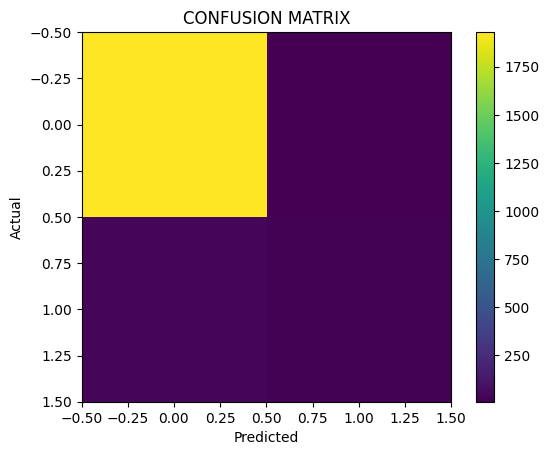

In [ ]:
cm=confusion_matrix(y_test,logp)
plt.imshow(cm)
plt.title("CONFUSION MATRIX")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()